Loading Block C model objects...
  Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
  Optimal threshold: 0.377

D1: Computing full metric comparison table...
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.7952     0.6196  0.8877  0.7298   0.8794
Decision Tree          0.8064     0.6337  0.8971  0.7428   0.8939
Random Forest          0.8090     0.6450  0.8607  0.7374   0.8971
XGBoost                0.8216     0.6678  0.8503  0.7481   0.9079

  Saved → D1_metric_comparison.csv

  Best value per metric:
    Accuracy     → XGBoost  (0.8216)
    Precision    → XGBoost  (0.6678)
    Recall       → Decision Tree  (0.8971)
    F1           → XGBoost  (0.7481)
    ROC-AUC      → XGBoost  (0.9079)

D2: Plotting ROC curves...


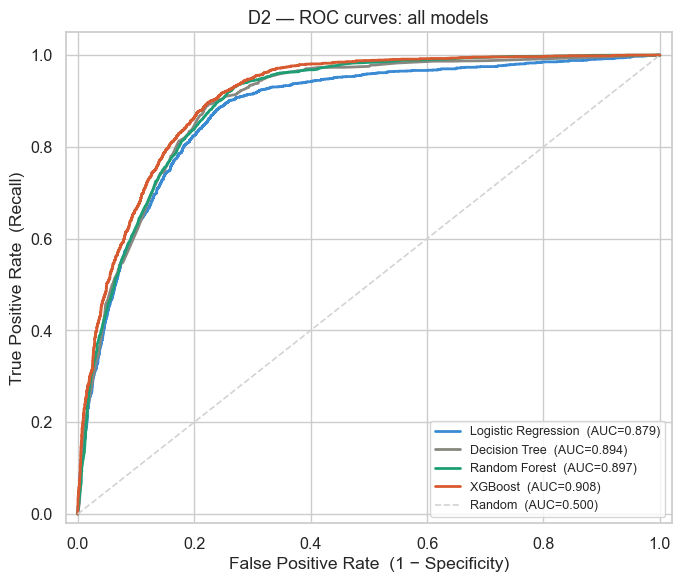

  Saved → ./outputs/phase4/block_d/D2_roc_curves.png

D3: Plotting Precision-Recall curves...


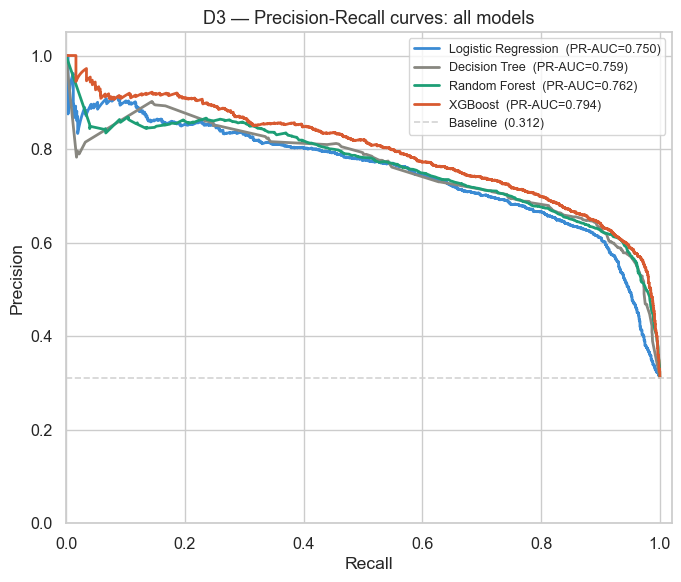

  Saved → ./outputs/phase4/block_d/D3_precision_recall_curves.png

D4: Plotting confusion matrices...


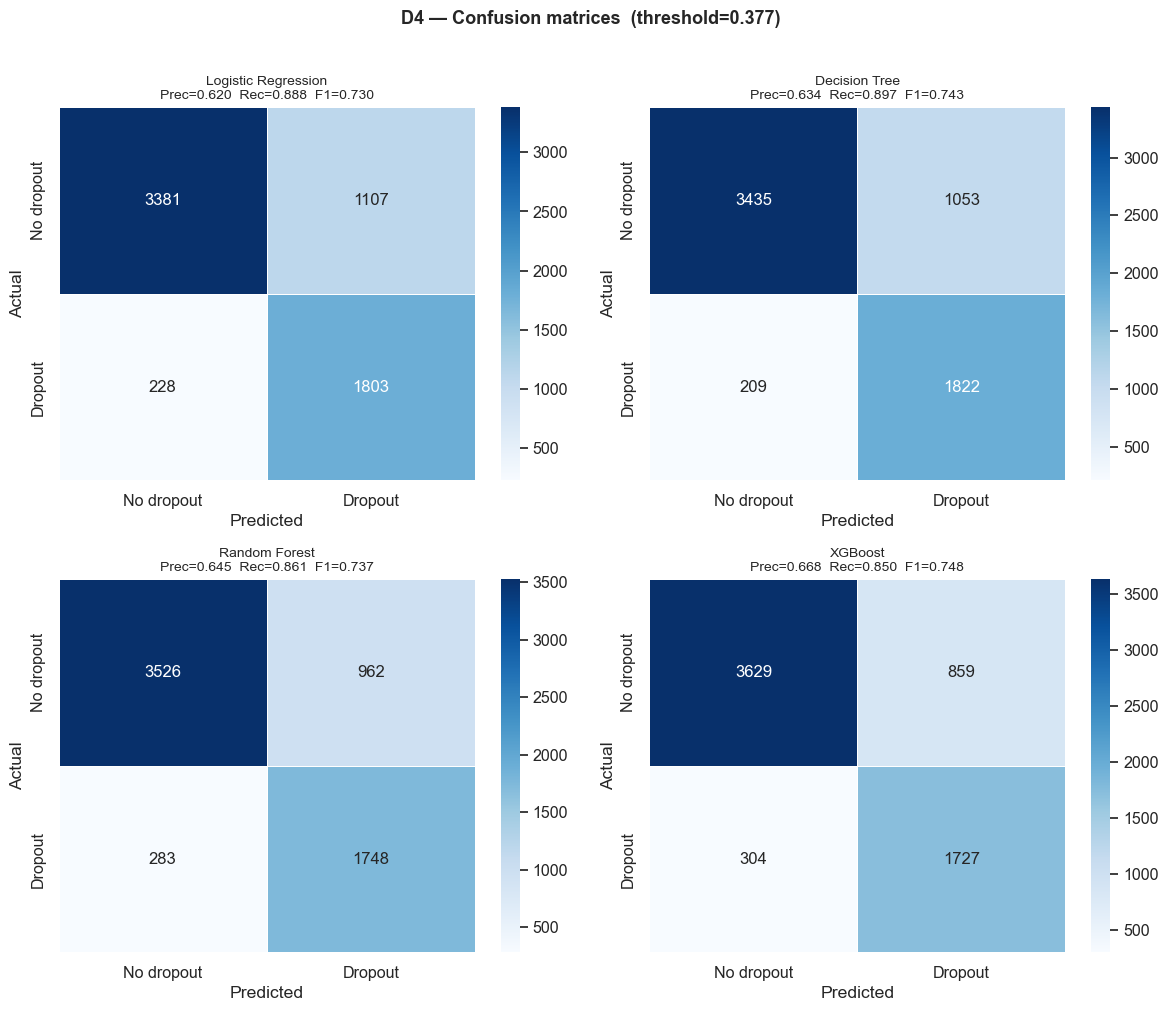

  Saved → ./outputs/phase4/block_d/D4_confusion_matrices.png

D5: Computing 5-fold CV AUC for all models...
  Logistic Regression       CV-AUC: 0.8759 ± 0.0021
  Decision Tree             CV-AUC: 0.9216 ± 0.0035
  Random Forest             CV-AUC: 0.9452 ± 0.0026
  XGBoost                   CV-AUC: 0.9535 ± 0.0023



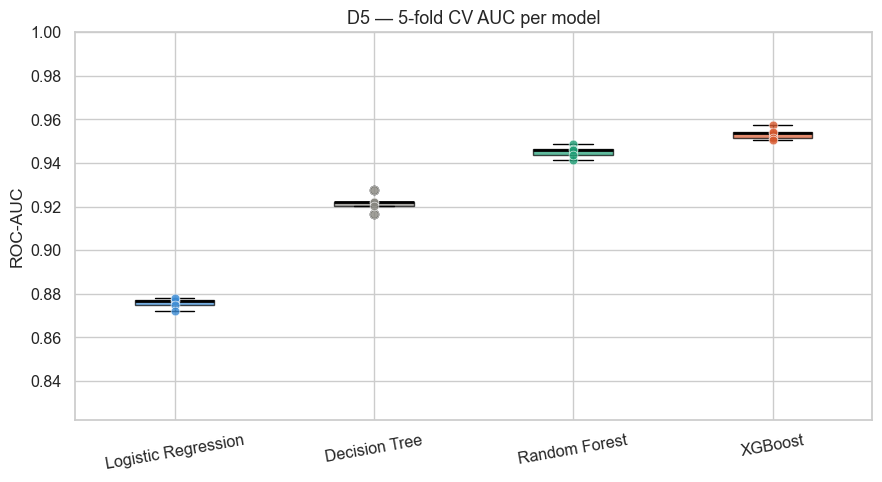

  Saved → ./outputs/phase4/block_d/D5_cv_auc_boxplot.png

D6: Plotting metric bar chart...


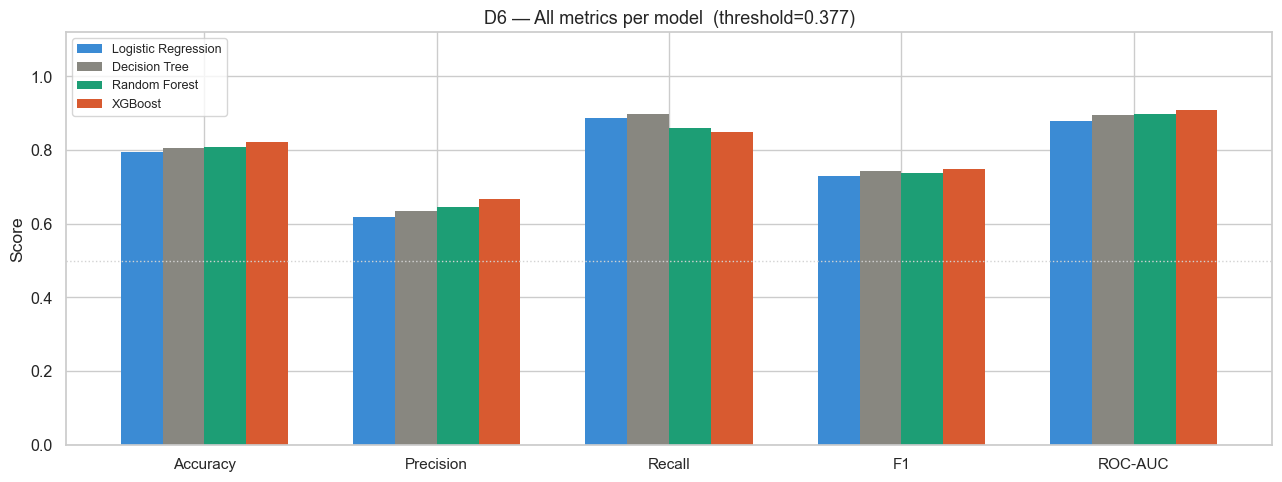

  Saved → ./outputs/phase4/block_d/D6_metric_bar_chart.png

D7: Best model selected
  Model    : XGBoost
  F1-score : 0.7481
  Recall   : 0.8503
  ROC-AUC  : 0.9079

  Saved → ./outputs/phase4/block_d/block_d_objects.pkl

BLOCK D COMPLETE — Model Comparison and Evaluation

  Charts saved to: ./outputs/phase4/block_d/
    D1_metric_comparison.csv
    D2_roc_curves.png
    D3_precision_recall_curves.png
    D4_confusion_matrices.png
    D5_cv_auc_boxplot.png
    D6_metric_bar_chart.png

─────────────────────────────────────────────────────────
Next → Run phase4_block_e_risk_scoring.py
─────────────────────────────────────────────────────────



In [1]:
"""
=============================================================
Phase 4 — Block D: Model Comparison and Evaluation
=============================================================
Goal: Evaluate all four trained models side by side and select
      the best one for the dropout risk scorer in Block E.

What we measure:
  Accuracy  — % of all predictions that are correct
  Precision — of predicted dropouts, how many are real
  Recall    — of real dropouts, how many did we catch
  F1-score  — harmonic mean of precision and recall
  ROC-AUC   — overall discrimination ability (0.5–1.0)
  CV-AUC    — cross-validated AUC (robust estimate)

For an early warning system, RECALL is the most important metric.
A missed dropout (False Negative) means a student we could have
helped but didn't. A false alarm (FP) means an advisor checks
in unnecessarily — far less harmful.

Visuals:
  D1 — Full metric comparison table (CSV)
  D2 — ROC curves (all models overlaid)
  D3 — Precision-Recall curves
  D4 — Confusion matrices (2x2 grid)
  D5 — Cross-validated AUC box plots
  D6 — Metric comparison bar chart
"""

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Config
BLOCK_C_PATH = './outputs/phase4/block_c/'
OUTPUT_PATH  = './outputs/phase4/block_d/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
MODEL_COLORS = {
    'Logistic Regression': COLORS['blue'],
    'Decision Tree':       COLORS['gray'],
    'Random Forest':       COLORS['teal'],
    'XGBoost':             COLORS['coral'],
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# Load Block C objects
print("Loading Block C model objects...")
with open(os.path.join(BLOCK_C_PATH, 'block_c_objects.pkl'), 'rb') as f:
    c = pickle.load(f)

models       = c['models']
probas       = c['probas']
auc_scores   = c['auc_scores']
X_test       = c['X_test']
y_test       = c['y_test']
X_train_res  = c['X_train_res']
y_train_res  = c['y_train_res']
best_thresh  = c['best_threshold']
FEATURES     = c['feature_names']
RANDOM_STATE = c['RANDOM_STATE']

MODEL_NAMES = list(models.keys())
print(f"  Models: {MODEL_NAMES}")
print(f"  Optimal threshold: {best_thresh:.3f}\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


# =============================================================
# D1: Full metric table
# =============================================================
print("D1: Computing full metric comparison table...")

rows = []
for name in MODEL_NAMES:
    proba  = probas[name]
    y_pred = (proba >= best_thresh).astype(int)
    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred),                     4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0),   4),
        'Recall':    round(recall_score(y_test, y_pred),                       4),
        'F1':        round(f1_score(y_test, y_pred),                           4),
        'ROC-AUC':   round(roc_auc_score(y_test, proba),                       4),
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
print(metrics_df.to_string())
print()

metrics_df.to_csv(os.path.join(OUTPUT_PATH, "D1_metric_comparison.csv"))
print("  Saved → D1_metric_comparison.csv\n")

print("  Best value per metric:")
for col in metrics_df.columns:
    best_model = metrics_df[col].idxmax()
    print(f"    {col:<12} → {best_model}  ({metrics_df[col].max():.4f})")
print()


# =============================================================
# D2: ROC curves overlaid
# =============================================================
print("D2: Plotting ROC curves...")

fig, ax = plt.subplots(figsize=(7, 6))
for name in MODEL_NAMES:
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    ax.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=2,
            label=f"{name}  (AUC={auc_scores[name]:.3f})")
ax.plot([0,1],[0,1], color='lightgray', linestyle='--', linewidth=1.2,
        label='Random  (AUC=0.500)')
ax.set_title("D2 — ROC curves: all models", fontsize=13)
ax.set_xlabel("False Positive Rate  (1 − Specificity)")
ax.set_ylabel("True Positive Rate  (Recall)")
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D2_roc_curves.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# D3: Precision-Recall curves
# =============================================================
print("D3: Plotting Precision-Recall curves...")

fig, ax = plt.subplots(figsize=(7, 6))
for name in MODEL_NAMES:
    prec, rec, _ = precision_recall_curve(y_test, probas[name])
    pr_auc = np.trapz(prec[::-1], rec[::-1])
    ax.plot(rec, prec, color=MODEL_COLORS[name], linewidth=2,
            label=f"{name}  (PR-AUC={pr_auc:.3f})")
ax.axhline(y_test.mean(), color='lightgray', linestyle='--', linewidth=1.2,
           label=f"Baseline  ({y_test.mean():.3f})")
ax.set_title("D3 — Precision-Recall curves: all models", fontsize=13)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=9)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D3_precision_recall_curves.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# D4: Confusion matrices — 2x2 grid
# =============================================================
print("D4: Plotting confusion matrices...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, name in zip(axes, MODEL_NAMES):
    y_pred = (probas[name] >= best_thresh).astype(int)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No dropout','Dropout'],
                yticklabels=['No dropout','Dropout'],
                linewidths=0.5, linecolor='white', annot_kws={'size':12})

    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec+1e-9)

    ax.set_title(f"{name}\nPrec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle(f"D4 — Confusion matrices  (threshold={best_thresh:.3f})",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D4_confusion_matrices.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# D5: 5-fold CV AUC box plots
# =============================================================
print("D5: Computing 5-fold CV AUC for all models...")

cv_results = {}
for name, model in models.items():
    cv_aucs = cross_val_score(model, X_train_res, y_train_res,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = cv_aucs
    print(f"  {name:<25} CV-AUC: {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")
print()

fig, ax = plt.subplots(figsize=(9, 5))
data_to_plot = [cv_results[n] for n in MODEL_NAMES]
bp = ax.boxplot(data_to_plot, labels=MODEL_NAMES, patch_artist=True,
                widths=0.4, medianprops=dict(color='black', linewidth=2))
for patch, name in zip(bp['boxes'], MODEL_NAMES):
    patch.set_facecolor(MODEL_COLORS[name])
    patch.set_alpha(0.7)
for i, (name, aucs) in enumerate(cv_results.items(), start=1):
    ax.scatter([i]*len(aucs), aucs, color=MODEL_COLORS[name],
               zorder=5, s=40, alpha=0.8, edgecolors='white', linewidths=0.5)
ax.set_title("D5 — 5-fold CV AUC per model", fontsize=13)
ax.set_ylabel("ROC-AUC")
ax.tick_params(axis='x', rotation=10)
ax.set_ylim(max(0.4, min(v.min() for v in cv_results.values())-0.05), 1.0)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D5_cv_auc_boxplot.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# D6: Metric comparison bar chart
# =============================================================
print("D6: Plotting metric bar chart...")

metric_cols = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x         = np.arange(len(metric_cols))
bar_width  = 0.18
offsets    = np.linspace(-(len(MODEL_NAMES)-1)/2, (len(MODEL_NAMES)-1)/2,
                         len(MODEL_NAMES)) * bar_width

fig, ax = plt.subplots(figsize=(13, 5))
for i, name in enumerate(MODEL_NAMES):
    vals = [metrics_df.loc[name, col] for col in metric_cols]
    ax.bar(x+offsets[i], vals, bar_width, color=MODEL_COLORS[name],
           label=name, edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.set_title(f"D6 — All metrics per model  (threshold={best_thresh:.3f})", fontsize=13)
ax.legend(fontsize=9)
ax.axhline(0.5, color='lightgray', linestyle=':', linewidth=1)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D6_metric_bar_chart.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# D7: Select best model and save
# =============================================================
best_model_name = metrics_df['F1'].idxmax()
best_model      = models[best_model_name]
best_proba      = probas[best_model_name]

print("=" * 55)
print("D7: Best model selected")
print("=" * 55)
print(f"  Model    : {best_model_name}")
print(f"  F1-score : {metrics_df.loc[best_model_name, 'F1']:.4f}")
print(f"  Recall   : {metrics_df.loc[best_model_name, 'Recall']:.4f}")
print(f"  ROC-AUC  : {metrics_df.loc[best_model_name, 'ROC-AUC']:.4f}\n")

save_path = os.path.join(OUTPUT_PATH, 'block_d_objects.pkl')
with open(save_path, 'wb') as f:
    pickle.dump({
        'metrics_df':      metrics_df,
        'cv_results':      cv_results,
        'best_model_name': best_model_name,
        'best_model':      best_model,
        'best_proba':      best_proba,
        'all_probas':      probas,
        'all_models':      models,
        'X_test':          X_test,
        'y_test':          y_test,
        'X_train_res':     X_train_res,
        'y_train_res':     y_train_res,
        'best_threshold':  best_thresh,
        'feature_names':   FEATURES,
        'RANDOM_STATE':    RANDOM_STATE,
    }, f)

print(f"  Saved → {save_path}")
print(f"""
{'='*60}
BLOCK D COMPLETE — Model Comparison and Evaluation
{'='*60}

  Charts saved to: {OUTPUT_PATH}
    D1_metric_comparison.csv
    D2_roc_curves.png
    D3_precision_recall_curves.png
    D4_confusion_matrices.png
    D5_cv_auc_boxplot.png
    D6_metric_bar_chart.png

─────────────────────────────────────────────────────────
Next → Run phase4_block_e_risk_scoring.py
─────────────────────────────────────────────────────────
""")